In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.stats import norm

In [11]:
# Establecer semilla aleatoria para que los resultados sean reproducibles [4]
np.random.seed(99)

# Generar población de 10,000 individuos con una distribución de Poisson (Lambda=10) [2]
population_size = 100_000
lam = 10
data_population = np.random.poisson(lam, population_size)
data_population

array([12, 13, 13, ...,  8, 12, 10], shape=(100000,), dtype=int32)

In [12]:
# Extraer una muestra aleatoria de tamaño n=200 de la población [2, 5]
sample_size = 100
data_sample = np.random.choice(data_population, sample_size)

# Calcular estadísticas básicas para comparar población vs muestra [2, 5]
pop_mean = np.mean(data_population)
pop_std = np.std(data_population)
sample_mean = np.mean(data_sample)  # x_bar
sample_std = np.std(data_sample)    # sigma_hat

print(f"Media población (mu): {pop_mean}")
print(f"Media muestra (x_bar): {sample_mean}")
print(f"Desviación estándard población: {pop_std}")
print(f"Desviación estándard muestra : {sample_std}")

Media población (mu): 9.99127
Media muestra (x_bar): 9.64
Desviación estándard población: 3.1671712595153423
Desviación estándard muestra : 2.7731570456791657


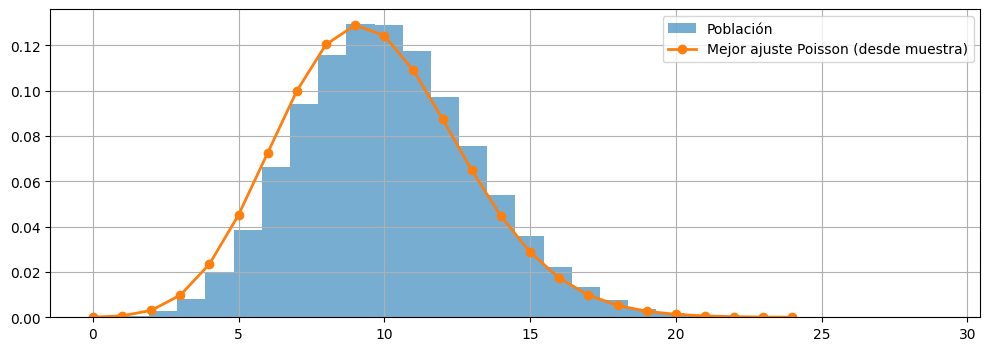

In [13]:
fig, ax = plt.subplots(figsize=(12,4))

ax.hist(data_population, bins=30,density=True, alpha=0.6, label='Población')

x = np.arange(0, 25)
ax.plot(x, poisson.pmf(x, sample_mean), 'o-', lw=2, label='Mejor ajuste Poisson (desde muestra)')
ax.grid()
ax.legend()
plt.show()

In [17]:

# Simulación para ver la distribución de la media muestral x_bar [3]
num_simulations = 1
sample_size_small = 1000  # Usando un n más pequeño para ver mayor variabilidad [7]
sample_means = []

for _ in range(num_simulations):
    resample = np.random.choice(data_population, sample_size_small)
    sample_means.append(np.mean(resample))



# fig, ax = plt.subplots(figsize=(12,4))

# ax.hist(sample_means, density=False,bins=105)
# ax.grid()
# plt.show()
print(f'El promedio de {num_simulations} es {np.mean(sample_means)}')
print(f'El promedio de la población es {pop_mean}')

El promedio de 1 es 10.064
El promedio de la población es 9.99127


In [18]:

# Simulación para ver la distribución de la media muestral x_bar [3]
num_simulations = 1000
sample_size_small = 100  # Usando un n más pequeño para ver mayor variabilidad [7]
sample_means = []

for _ in range(num_simulations):
    resample = np.random.choice(data_population, sample_size_small)
    sample_means.append(np.mean(resample))



# fig, ax = plt.subplots(figsize=(12,4))

# ax.hist(sample_means, density=False,bins=105)
# ax.grid()
# plt.show()
print(f'El promedio de {num_simulations} es {np.mean(sample_means)}')
print(f'El promedio de la población es {pop_mean}')

El promedio de 10 es 10.026
El promedio de la población es 9.99127


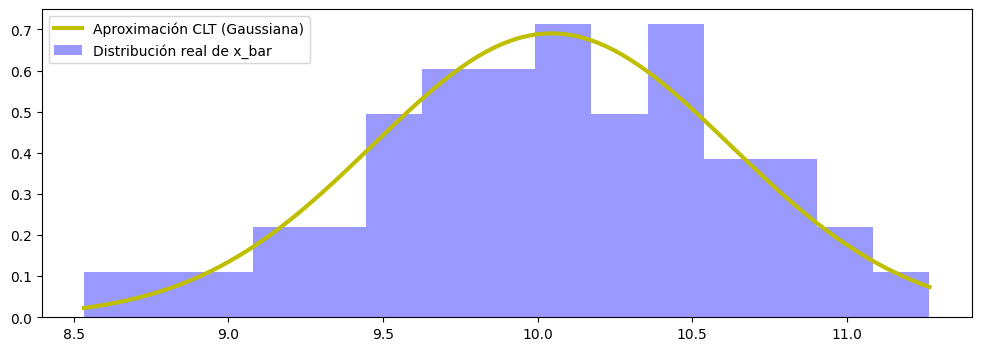

In [8]:
# Calcular la aproximación normal teórica usando el error estándar 
# Error estándar = Desviación estándar población / raíz cuadrada de n
standard_error = pop_std / np.sqrt(sample_size_small)

# Crear curva Gaussiana centrada en mu
x_axis = np.linspace(min(sample_means), max(sample_means), 100)

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(x_axis, norm.pdf(x_axis, pop_mean, standard_error), 'y-', lw=3, label='Aproximación CLT (Gaussiana)')

# Superponer con el histograma de las medias muestrales de la simulación [8]
ax.hist(sample_means, bins=15, density=True, alpha=0.4, color='blue', label='Distribución real de x_bar')

ax.legend()
plt.show()
